# load the kaggle data

In [1]:
from pathlib import Path
import pandas as pd

kDist_path_bb = Path("../data/sorted_k_dist/results_kdist_bertbase_sample")

list(kDist_path_bb.iterdir())

[PosixPath('../data/sorted_k_dist/results_kdist_bertbase_sample/k_distance_bb_2nd_last_10.csv'),
 PosixPath('../data/sorted_k_dist/results_kdist_bertbase_sample/k_distance_bb_2nd_last_100.csv'),
 PosixPath('../data/sorted_k_dist/results_kdist_bertbase_sample/k_distance_bb_2nd_last_5.csv'),
 PosixPath('../data/sorted_k_dist/results_kdist_bertbase_sample/k_distance_bb_2nd_last_50.csv'),
 PosixPath('../data/sorted_k_dist/results_kdist_bertbase_sample/k_distance_bb_last_10.csv'),
 PosixPath('../data/sorted_k_dist/results_kdist_bertbase_sample/k_distance_bb_last_100.csv'),
 PosixPath('../data/sorted_k_dist/results_kdist_bertbase_sample/k_distance_bb_last_5.csv'),
 PosixPath('../data/sorted_k_dist/results_kdist_bertbase_sample/k_distance_bb_last_50.csv'),
 PosixPath('../data/sorted_k_dist/results_kdist_bertbase_sample/k_distance_bb_mean_last4_10.csv'),
 PosixPath('../data/sorted_k_dist/results_kdist_bertbase_sample/k_distance_bb_mean_last4_100.csv'),
 PosixPath('../data/sorted_k_dist/results

In [2]:
import re
import pandas as pd
from pathlib import Path

files = Path('../data/sorted_k_dist/results_kdist_bertbase_sample').glob('*.csv')

pattern = re.compile(r'k_distance_(bb)_(.+)_(\d+)\.csv')

dfs = []
for f in files:
    m = pattern.match(f.name)
    if not m:
        continue
    prefix, layer, k = m.groups()

    df = pd.read_csv(f)
    df['model'] = 'bert-base' if prefix == 'bb' else prefix
    df['layer'] = layer
    df['k'] = int(k)
    dfs.append(df)

bert_base = pd.concat(dfs, ignore_index=True)


print(bert_base.shape)
bert_base.head()

(599028, 6)


,rank,id,k_distance,model,layer,k
0,0,537643,0.030846,bert-base,2nd_last,10
1,1,537628,0.030949,bert-base,2nd_last,10
2,2,537608,0.030956,bert-base,2nd_last,10
3,3,537594,0.032708,bert-base,2nd_last,10
4,4,537593,0.033746,bert-base,2nd_last,10


In [3]:
files = Path('../data/sorted_k_dist/results_kdist_scibert_sample').glob('*.csv')

pattern = re.compile(r'k_distance_(sb)_(.+)_(\d+)\.csv')

dfs = []
for f in files:
    m = pattern.match(f.name)
    if not m:
        continue
    prefix, layer, k = m.groups()

    df = pd.read_csv(f)
    df['model'] = 'SciBERT' if prefix == 'sb' else prefix
    df['layer'] = layer
    df['k'] = int(k)
    dfs.append(df)

sciBERT = pd.concat(dfs, ignore_index=True)


print(sciBERT.shape)
sciBERT.head()

(599028, 6)


,rank,id,k_distance,model,layer,k
0,0,537643,0.016476,SciBERT,2nd_last,10
1,1,537628,0.017329,SciBERT,2nd_last,10
2,2,537608,0.017432,SciBERT,2nd_last,10
3,3,537594,0.017832,SciBERT,2nd_last,10
4,4,537593,0.018123,SciBERT,2nd_last,10


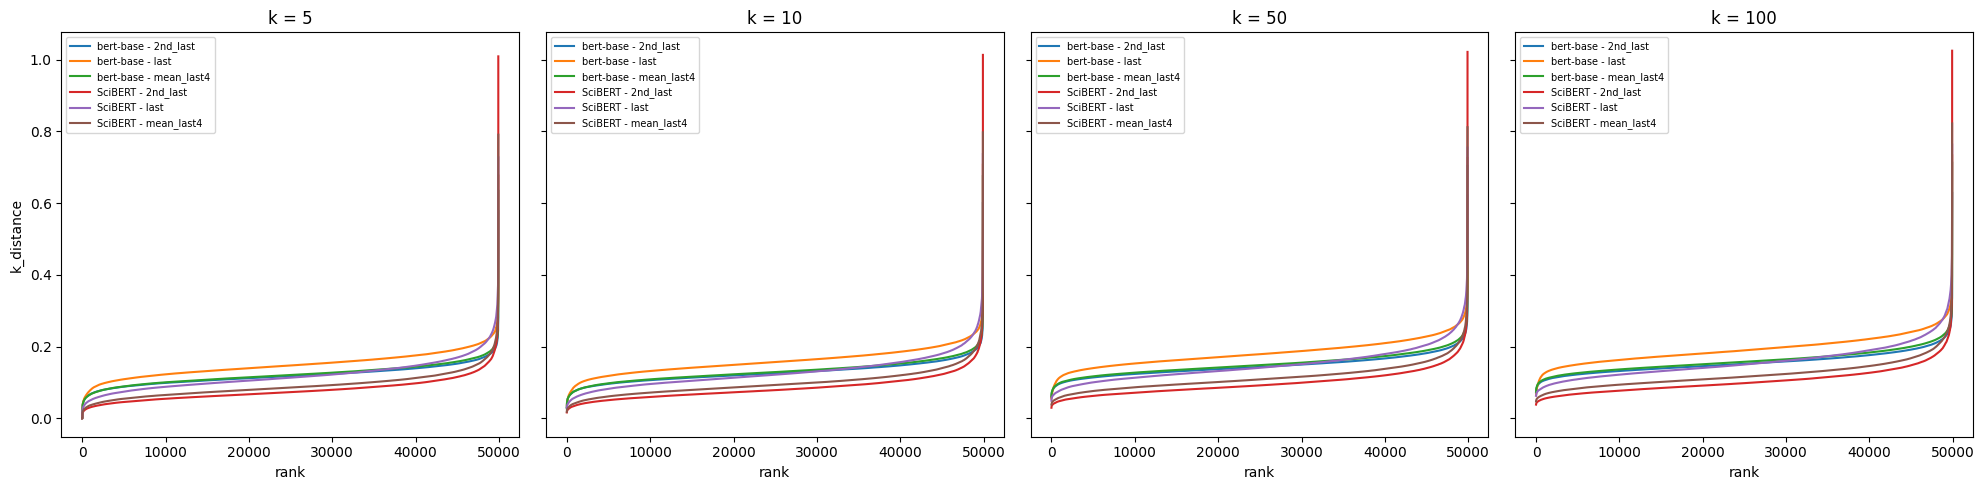

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# combine both models
all_models = pd.concat([bert_base, sciBERT], ignore_index=True)  # bb_all = your bert-base concat result
all_models['model_layer'] = all_models['model'] + ' - ' + all_models['layer']

# one subplot per k value
ks = sorted(all_models['k'].unique())
fig, axes = plt.subplots(1, len(ks), figsize=(5 * len(ks), 5), sharey=True)

for ax, k in zip(axes, ks):
    subset = all_models[all_models['k'] == k]
    sns.lineplot(
        data=subset,
        x='rank', y='k_distance',
        hue='model_layer',
        ax=ax
    )
    ax.set_title(f'k = {k}')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

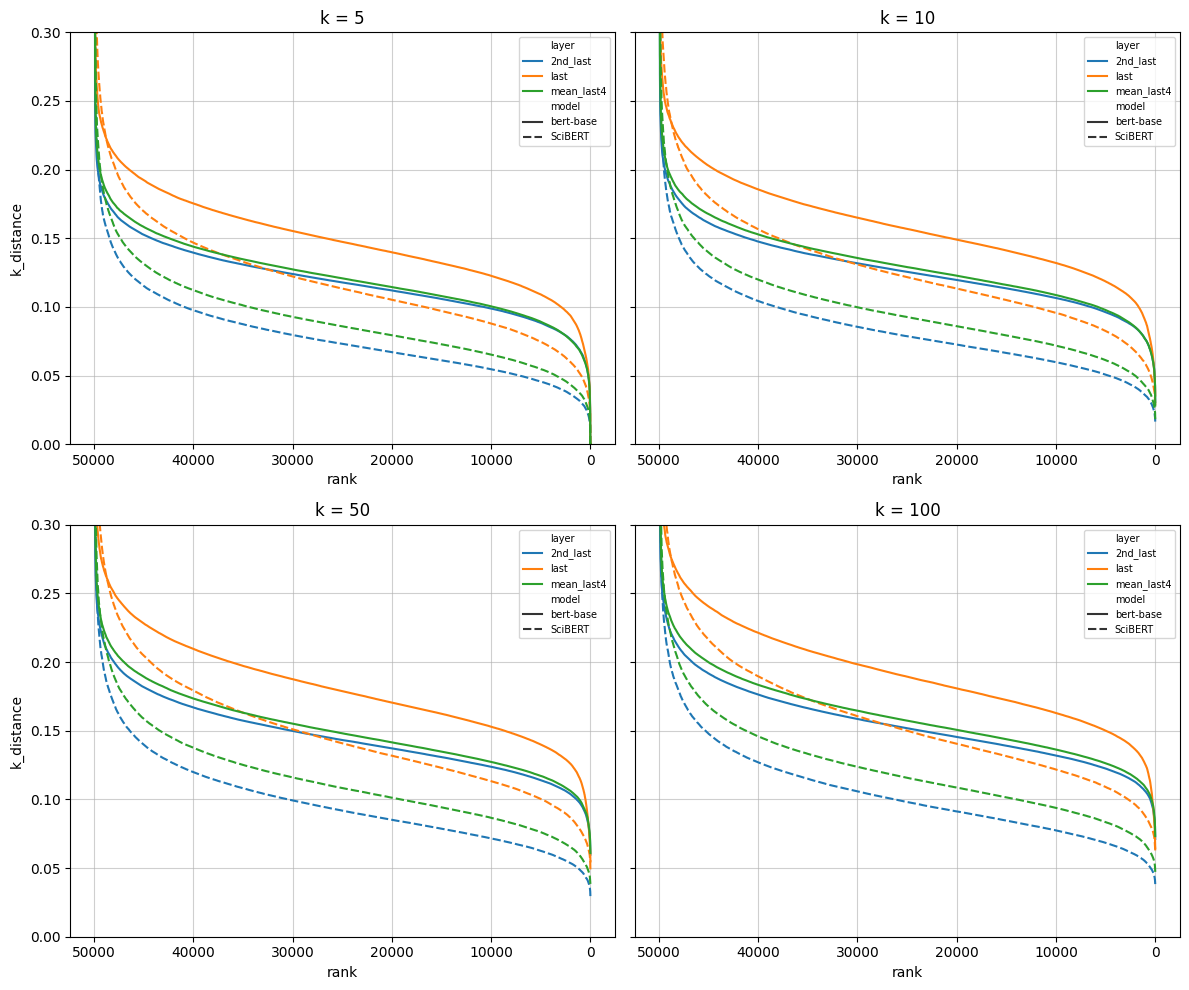

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

all_models = pd.concat([bert_base, sciBERT], ignore_index=True)

ks = sorted(all_models['k'].unique())
n_rows = 2
n_cols = int(np.ceil(len(ks) / n_rows))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows), sharey=True)
axes = axes.flatten()

for ax, k in zip(axes, ks):
    subset = all_models[all_models['k'] == k]
    sns.lineplot(
        data=subset,
        x='rank', y='k_distance',
        hue='layer',
        style='model',
        ax=ax
    )
    ax.set_title(f'k = {k}')
    ax.set_ylim(0, 0.3)
    ax.invert_xaxis()
    ax.grid(True, alpha=0.6)
    ax.set_axisbelow(True)
    ax.legend(fontsize=7)

for ax in axes[len(ks):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

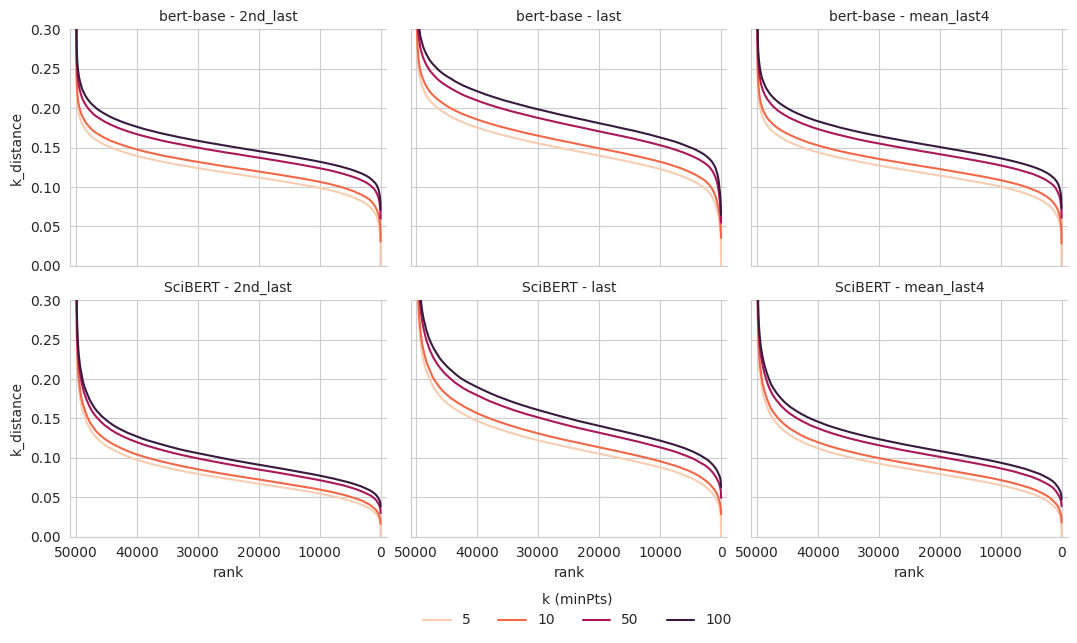

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

all_models['model_layer'] = all_models['model'] + ' - ' + all_models['layer']
all_models['k'] = all_models['k'].astype(str)

sns.set_style("whitegrid")

hue_order = ['5', '10', '50', '100']

# sample 4 well-spaced points across the full rocket colormap
rocket_cmap = sns.color_palette("rocket", as_cmap=True)
sample_points = [0.92, 0.68, 0.42, 0.15] #[0.15, 0.42, 0.68, 0.92]  # spread across dark -> light
colors = [rocket_cmap(p) for p in sample_points]

palette = dict(zip(hue_order, colors))

g = sns.relplot(
    data=all_models,
    x='rank', y='k_distance',
    hue='k', hue_order=hue_order,
    palette=palette,
    col='model_layer', col_wrap=3,
    kind='line',
    height=3, aspect=1.2,
    facet_kws={'sharey': True}
)
g.set_titles('{col_name}')
g.set(ylim=(0, 0.3))
rank_min, rank_max = all_models['rank'].min() - 1000, all_models['rank'].max() + 1000
g.set(xlim=(rank_max, rank_min))

sns.move_legend(
    g, "lower center",
    bbox_to_anchor=(0.5, -0.075),
    ncol=len(hue_order),
    title='k (minPts)'
)

plt.show()

## Check the k-distnaces together

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# columns that define the observation independently of the model
keys = ["id", "layer", "k"]

paired = (
    all_models.pivot_table(
        index=keys,
        columns="model",
        values="k_distance",
        aggfunc="first"
    )
    .dropna(subset=["bert-base", "SciBERT"])
    .reset_index()
)

print(paired.head())

model  id     layer    k   SciBERT  bert-base
0       1  2nd_last   10  0.069128   0.116145
1       1  2nd_last  100  0.087499   0.141875
2       1  2nd_last    5  0.063681   0.108514
3       1  2nd_last   50  0.081550   0.133621
4       1      last   10  0.108671   0.144589


In [27]:
paired[
    (paired["layer"] == "2nd_last") &
    (paired["k"] == "10")]

model,id,layer,k,SciBERT,bert-base
0,1,2nd_last,10,0.069128,0.116145
12,25,2nd_last,10,0.069126,0.116145
24,26,2nd_last,10,0.069125,0.116145
36,42,2nd_last,10,0.069124,0.116145
48,46,2nd_last,10,0.069123,0.116143
...,...,...,...,...,...
598968,537593,2nd_last,10,0.018123,0.033746
598980,537594,2nd_last,10,0.017832,0.032708
598992,537608,2nd_last,10,0.017432,0.030956
599004,537628,2nd_last,10,0.017329,0.030949


In [28]:
from scipy.stats import pearsonr, spearmanr

subset = paired[
    (paired["layer"] == "2nd_last") &
    (paired["k"] == "10")
]

pearson_r, pearson_p = pearsonr(
    subset["bert-base"],
    subset["SciBERT"]
)

spearman_r, spearman_p = spearmanr(
    subset["bert-base"],
    subset["SciBERT"]
)

print(f"N = {len(subset)}")
print(f"Pearson r  = {pearson_r:.4f}, p = {pearson_p:.4g}")
print(f"Spearman ρ = {spearman_r:.4f}, p = {spearman_p:.4g}")

N = 49919
Pearson r  = 0.9775, p = 0
Spearman ρ = 1.0000, p = 0


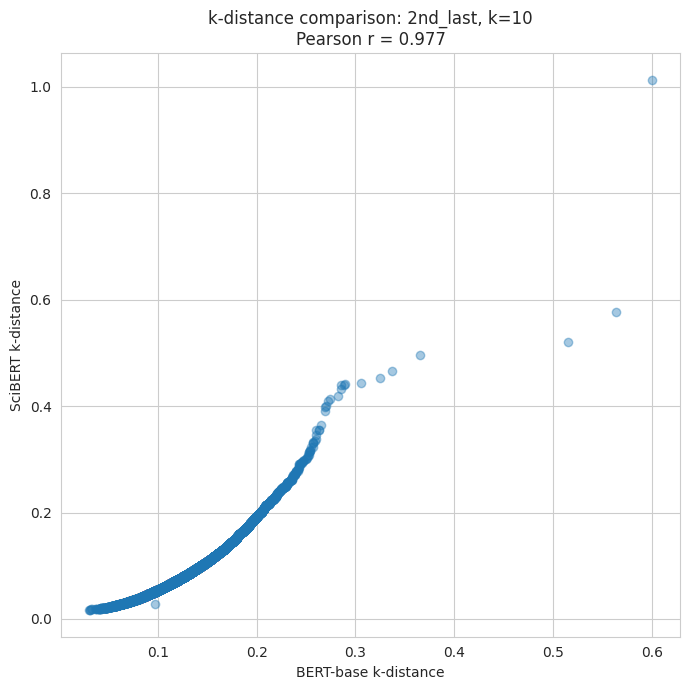

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

plt.scatter(
    subset["bert-base"],
    subset["SciBERT"],
    alpha=0.4
)

plt.xlabel("BERT-base k-distance")
plt.ylabel("SciBERT k-distance")
plt.title(
    f"k-distance comparison: 2nd_last, k=10\n"
    f"Pearson r = {pearson_r:.3f}"
)

plt.tight_layout()
plt.show()

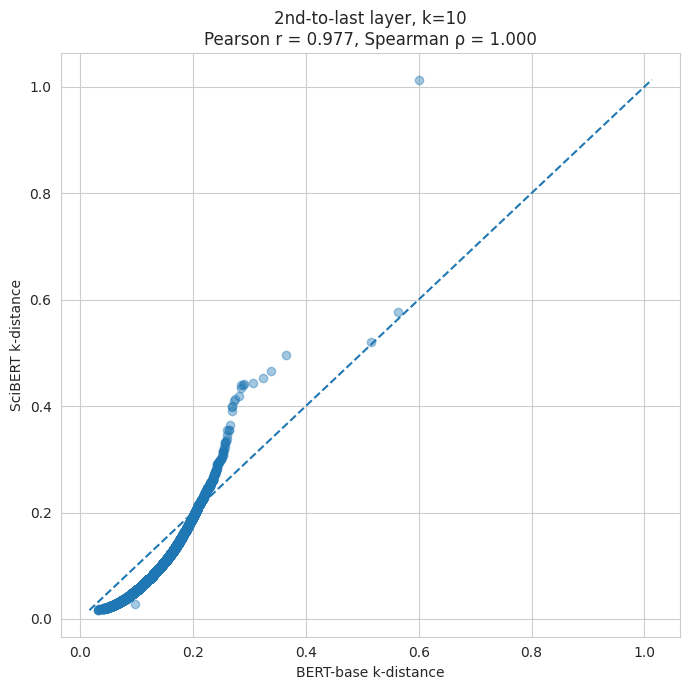

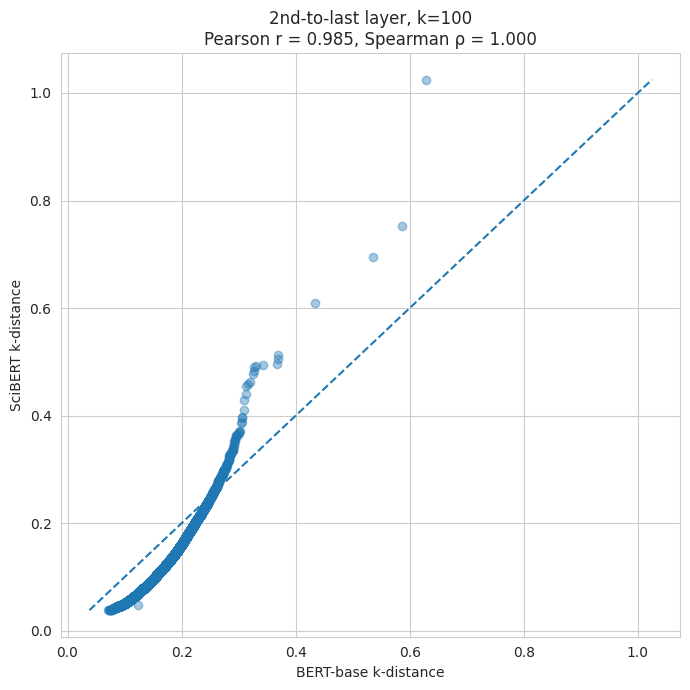

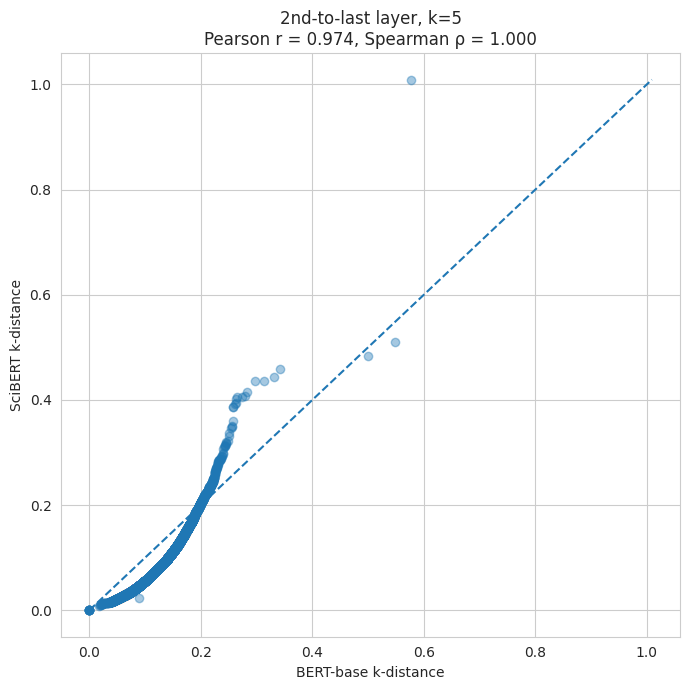

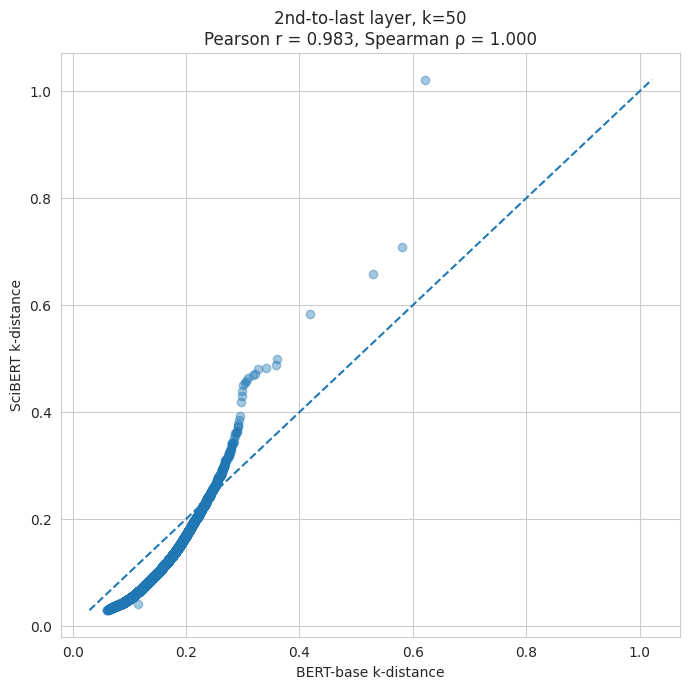

     k      n  pearson_r  pearson_p  spearman_r  spearman_p
0   10  49919   0.977455        0.0    0.999999         0.0
1  100  49919   0.984567        0.0    0.999999         0.0
2    5  49919   0.974018        0.0    0.999999         0.0
3   50  49919   0.982930        0.0    0.999999         0.0


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# Keep only the 2nd-to-last layer
paired_2nd_last = paired[
    paired["layer"] == "2nd_last"
].copy()

# Get all k values
ks = sorted(paired_2nd_last["k"].unique())

# Store correlations
results = []

for k in ks:
    subset = paired_2nd_last[
        paired_2nd_last["k"] == k
    ].dropna(subset=["bert-base", "SciBERT"])

    pearson_r, pearson_p = pearsonr(
        subset["bert-base"],
        subset["SciBERT"]
    )

    spearman_r, spearman_p = spearmanr(
        subset["bert-base"],
        subset["SciBERT"]
    )

    results.append({
        "k": k,
        "n": len(subset),
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p
    })

    # Scatterplot
    plt.figure(figsize=(7, 7))

    plt.scatter(
        subset["bert-base"],
        subset["SciBERT"],
        alpha=0.4
    )

    # Add y=x reference line
    min_val = min(
        subset["bert-base"].min(),
        subset["SciBERT"].min()
    )
    max_val = max(
        subset["bert-base"].max(),
        subset["SciBERT"].max()
    )

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        "--"
    )

    plt.xlabel("BERT-base k-distance")
    plt.ylabel("SciBERT k-distance")

    plt.title(
        f"2nd-to-last layer, k={k}\n"
        f"Pearson r = {pearson_r:.3f}, "
        f"Spearman ρ = {spearman_r:.3f}"
    )

    plt.tight_layout()
    plt.show()


# Correlation results as dataframe
correlations = pd.DataFrame(results)

print(correlations)

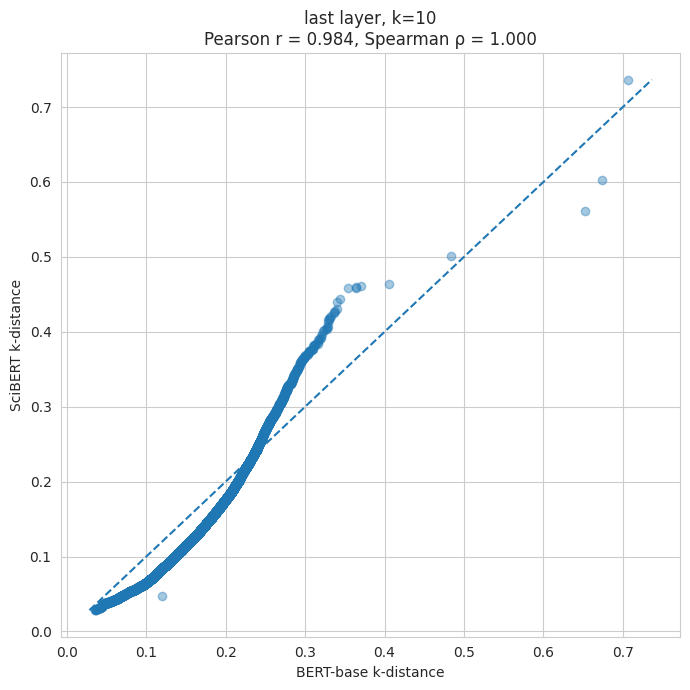

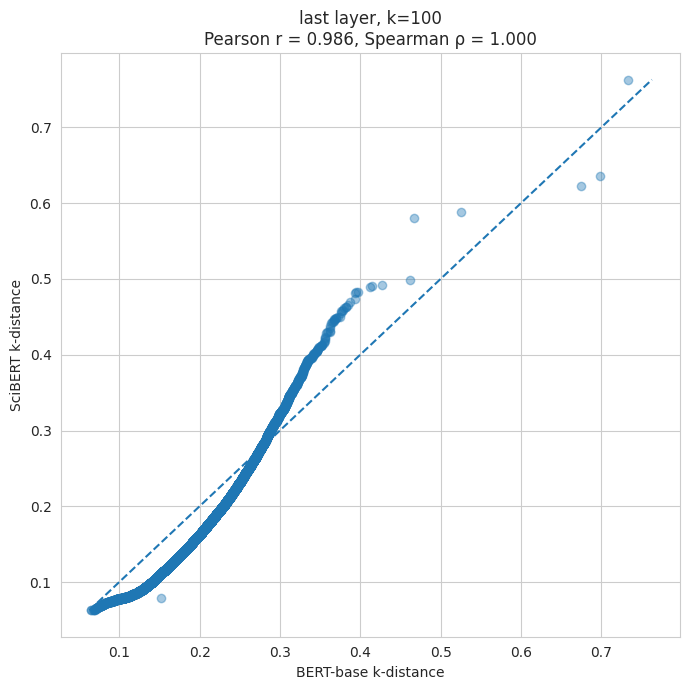

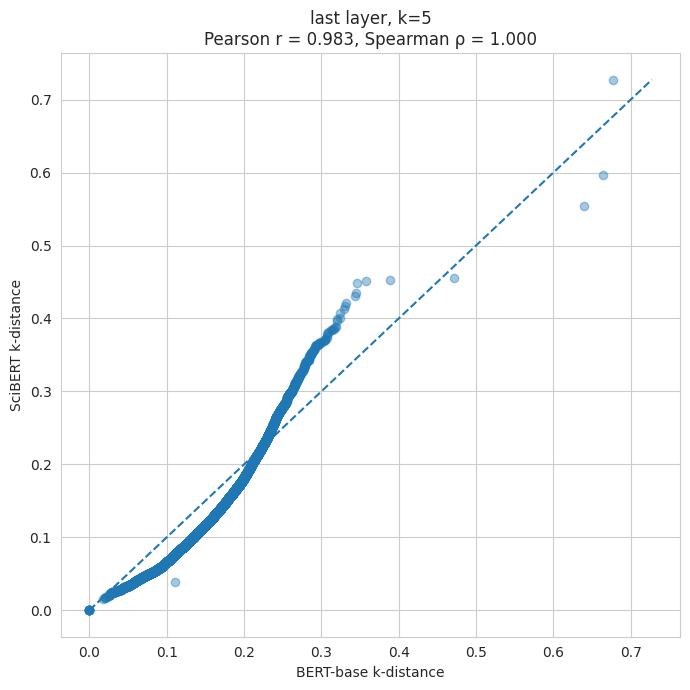

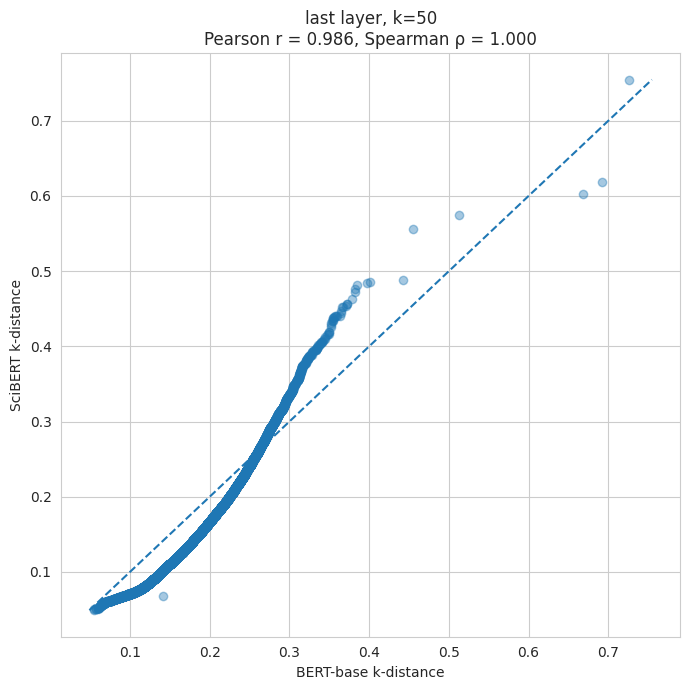

     k      n  pearson_r  pearson_p  spearman_r  spearman_p
0   10  49919   0.983638        0.0    0.999999         0.0
1  100  49919   0.986182        0.0    0.999999         0.0
2    5  49919   0.982969        0.0    0.999999         0.0
3   50  49919   0.985627        0.0    0.999999         0.0


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# Keep only the 2nd-to-last layer
paired_last = paired[
    paired["layer"] == "last"
].copy()

# Get all k values
ks = sorted(paired_last["k"].unique())

# Store correlations
results = []

for k in ks:
    subset = paired_last[
        paired_last["k"] == k
    ].dropna(subset=["bert-base", "SciBERT"])

    pearson_r, pearson_p = pearsonr(
        subset["bert-base"],
        subset["SciBERT"]
    )

    spearman_r, spearman_p = spearmanr(
        subset["bert-base"],
        subset["SciBERT"]
    )

    results.append({
        "k": k,
        "n": len(subset),
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p
    })

    # Scatterplot
    plt.figure(figsize=(7, 7))

    plt.scatter(
        subset["bert-base"],
        subset["SciBERT"],
        alpha=0.4
    )

    # Add y=x reference line
    min_val = min(
        subset["bert-base"].min(),
        subset["SciBERT"].min()
    )
    max_val = max(
        subset["bert-base"].max(),
        subset["SciBERT"].max()
    )

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        "--"
    )

    plt.xlabel("BERT-base k-distance")
    plt.ylabel("SciBERT k-distance")

    plt.title(
        f"last layer, k={k}\n"
        f"Pearson r = {pearson_r:.3f}, "
        f"Spearman ρ = {spearman_r:.3f}"
    )

    plt.tight_layout()
    plt.show()


# Correlation results as dataframe
correlations = pd.DataFrame(results)

print(correlations)

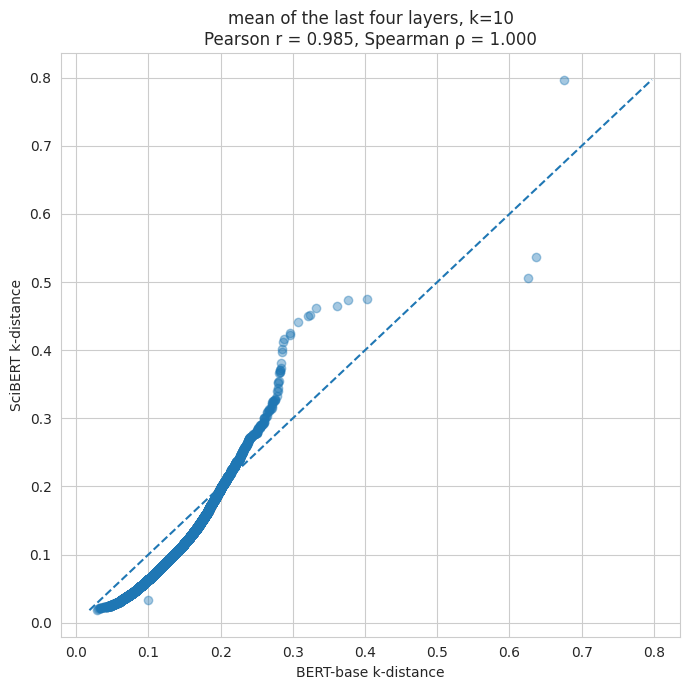

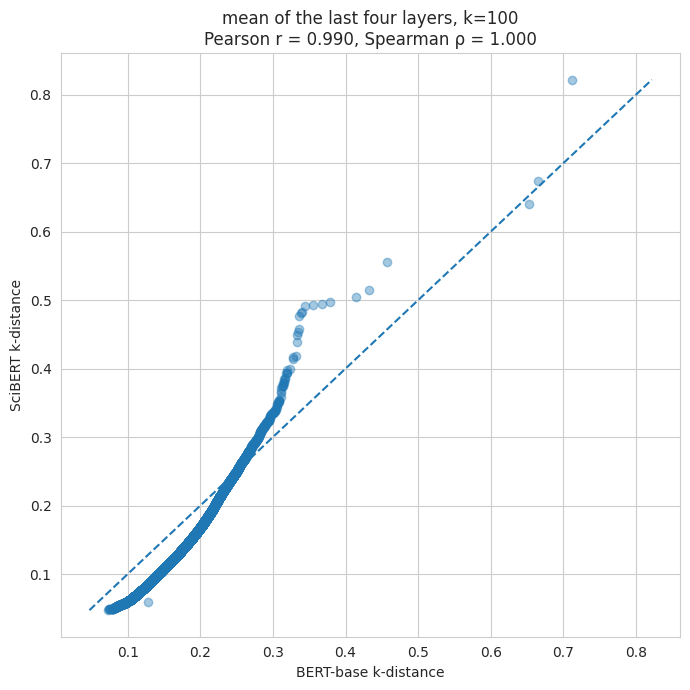

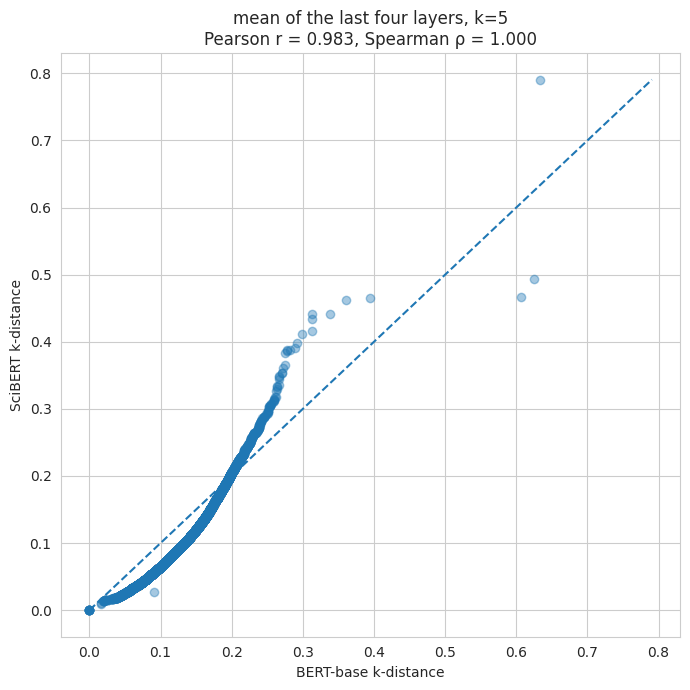

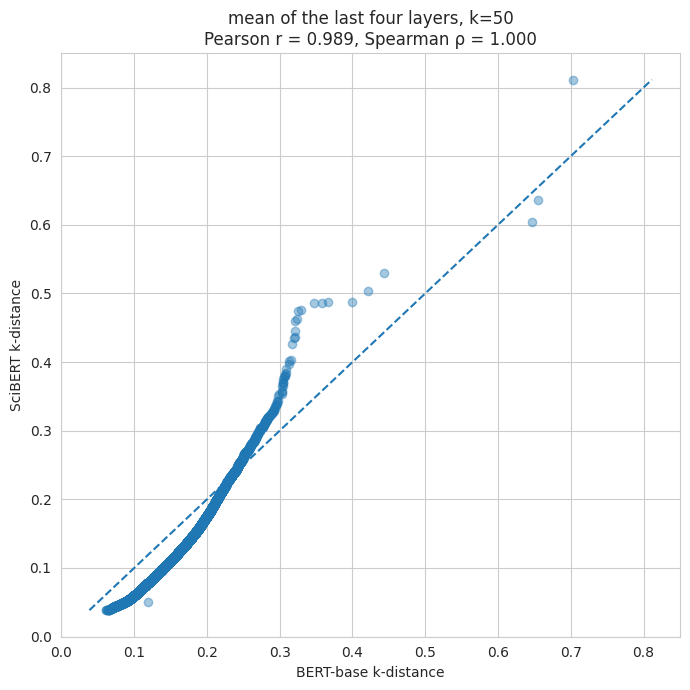

     k      n  pearson_r  pearson_p  spearman_r  spearman_p
0   10  49919   0.984901        0.0    0.999999         0.0
1  100  49919   0.989524        0.0    0.999999         0.0
2    5  49919   0.983155        0.0    0.999999         0.0
3   50  49919   0.988589        0.0    0.999999         0.0


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# Keep only the 2nd-to-last layer
paired_mean = paired[
    paired["layer"] == "mean_last4"
].copy()

# Get all k values
ks = sorted(paired_mean["k"].unique())

# Store correlations
results = []

for k in ks:
    subset = paired_mean[
        paired_mean["k"] == k
    ].dropna(subset=["bert-base", "SciBERT"])

    pearson_r, pearson_p = pearsonr(
        subset["bert-base"],
        subset["SciBERT"]
    )

    spearman_r, spearman_p = spearmanr(
        subset["bert-base"],
        subset["SciBERT"]
    )

    results.append({
        "k": k,
        "n": len(subset),
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p
    })

    # Scatterplot
    plt.figure(figsize=(7, 7))

    plt.scatter(
        subset["bert-base"],
        subset["SciBERT"],
        alpha=0.4
    )

    # Add y=x reference line
    min_val = min(
        subset["bert-base"].min(),
        subset["SciBERT"].min()
    )
    max_val = max(
        subset["bert-base"].max(),
        subset["SciBERT"].max()
    )

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        "--"
    )

    plt.xlabel("BERT-base k-distance")
    plt.ylabel("SciBERT k-distance")

    plt.title(
        f"mean of the last four layers, k={k}\n"
        f"Pearson r = {pearson_r:.3f}, "
        f"Spearman ρ = {spearman_r:.3f}"
    )

    plt.tight_layout()
    plt.show()


# Correlation results as dataframe
correlations = pd.DataFrame(results)

print(correlations)

## distance between k values